In [1]:
import numpy as np 
import pandas as pd

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.set_index('customerID')

In [16]:
print(df.columns.tolist())
print(
len(df.columns.tolist())
)
df['customerID'].count()

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'mapped_churn']
22


7043

In [17]:
df['TotalCharges'] = df['TotalCharges'].replace({" " : np.nan})
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [6]:
df.duplicated().sum()
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges']]
df.columns.tolist()
df[df['Churn'] == "Yes"]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,mapped_churn
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7021,1699-HPSBG,Male,0,No,No,12,Yes,No,DSL,No,...,Yes,Yes,No,One year,Yes,Electronic check,59.80,727.80,Yes,1
7026,8775-CEBBJ,Female,0,No,No,9,Yes,No,DSL,No,...,No,No,No,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1


In [8]:
# maping churn yes and no to zeros and ones 
df['TotalCharges']= df['TotalCharges'].fillna(0)
mapping = {"Yes":1, "No":0} 
df['mapped_churn'] = df['Churn'].map(mapping)
df.head(3)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,mapped_churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1


In [9]:
df_final = (
    df.groupby('Contract').agg(
        Churn_sum = ('mapped_churn','sum'),
        contract_count  = ('mapped_churn','count')
    ).eval(
        'churn_rate =  (Churn_sum /contract_count )*100'
    )
)
df_final

,Churn_sum,contract_count,churn_rate
Contract,,,
Month-to-month,1655,3875,42.709677
One year,166,1473,11.269518
Two year,48,1695,2.831858


In [10]:
df_latest = (
    df.assign(
        segment = lambda x: np.where(x['tenure']>12,
        np.where(x['tenure']<=48,'Established','Veteran')                            
        ,"New")
    )
)
# df_latest[['tenure','segment']]
df_latest

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,mapped_churn,segment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,New
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,Established
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,New
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,Established
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0,Established
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,Veteran
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,New
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1,New


In [11]:
df_latest_last = (
    df_latest.groupby(['Contract','segment']).agg(
        Churn_sum = ('mapped_churn','sum'),
        contract_count  = ('mapped_churn','count')
    ).eval(
        'churn_rate =  (Churn_sum /contract_count )*100'
    )
)
df_latest_last

Churn_sum  contract_count  churn_rate
Contract       segment                                           
Month-to-month Established        542            1539   35.217674
               New               1024            1994   51.354062
               Veteran             89             342   26.023392
One year       Established         71             715    9.930070
               New                 13             124   10.483871
               Veteran             82             634   12.933754
Two year       Established          6             364    1.648352
               New                  0              68    0.000000
               Veteran             42            1263    3.325416

In [12]:
df_analysis = (
    df_latest
    .assign(spend_tier = lambda x: np.where(x['MonthlyCharges'] > 80, 'High', 'Low'))
    .groupby(['Contract', 'segment', 'spend_tier'])
    .agg(
        Churn_sum=('mapped_churn', 'sum'),
        customer_count=('mapped_churn', 'count')
    )
    .eval('churn_rate = (Churn_sum / customer_count) * 100')
    .sort_values('churn_rate', ascending=False)
)

In [13]:
df_analysis.head(6)

Churn_sum  customer_count  churn_rate
Contract       segment     spend_tier                                       
Month-to-month New         High              341             464   73.491379
               Established High              352             757   46.499339
               New         Low               683            1530   44.640523
               Veteran     High               71             244   29.098361
One year       New         High                2               7   28.571429
Month-to-month Established Low               190             782   24.296675

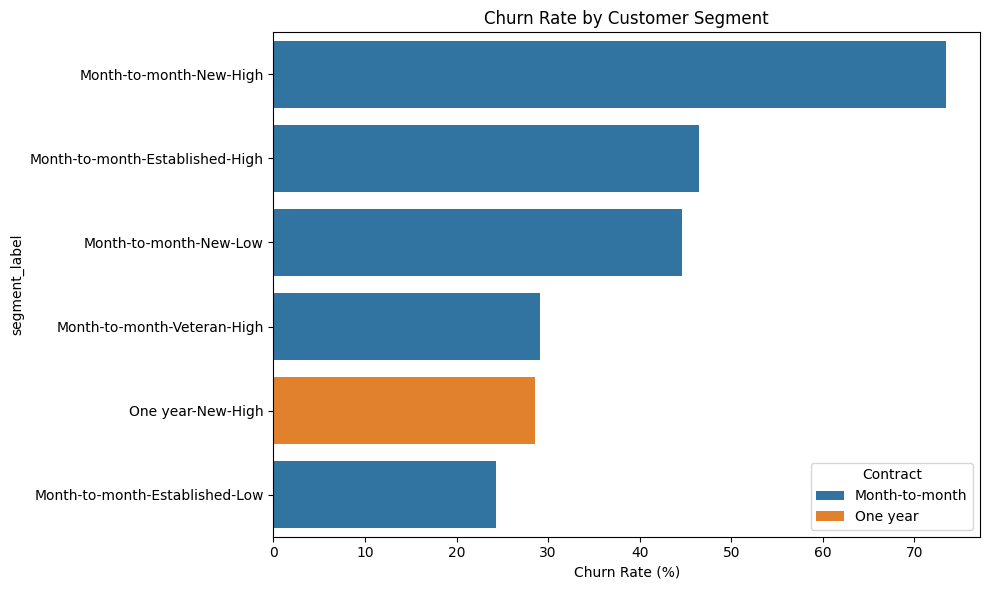

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


plot_data = df_analysis.reset_index()
plot_data['segment_label'] = (plot_data['Contract'] + '-' + 
                               plot_data['segment'] + '-' + 
                               plot_data['spend_tier'])

top6 = plot_data.head(6)
plt.figure(figsize=(10, 6))
sns.barplot(data=top6, x='churn_rate', y='segment_label', 
            hue='Contract', dodge=False)
plt.title('Churn Rate by Customer Segment')
plt.xlabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=300)
plt.show()